# The panel, examined

This notebook reads `../data/training_set.parquet` only — no re-fetch, no write. It exists because
nobody had looked at the panel directly before this session: NDVI < 0 sat undetected in 5% of rows
until it was found here. Every number below is reproduced from the committed parquet; where a number
is already recorded in `docs/FACTS.md` or `docs/CONCEPTS.md`, this notebook shows the computation
that produces it.

## 1. Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.width', 140); pd.set_option('display.max_columns', 50)

panel = pd.read_parquet('../data/training_set.parquet')
panel['obs_date'] = pd.to_datetime(panel['obs_date'])
panel['label_date'] = pd.to_datetime(panel['label_date'])
print(panel.shape)
panel.head(3)

(4596, 35)


,gdd_90,gdd_since_onset,tmax_mean_30,tmin_mean_30,diurnal_range_30,heat_stress_days,rain_30,rain_90,et0_90,water_satisfaction_30,water_deficit_30,dry_spell_30,dry_spell_90,rain_anomaly_30,rh_mean_30,radiation_90,days_since_onset,stage_kc,ndvi,ndmi,evi,vci,ndvi_z_peer,rvi,vh_vv_ratio,rvi_z_peer,latitude,longitude,elevation,label,forward_z,site_id,cluster,obs_date,label_date
0,1231.8,1231.8,28.34,20.13,8.21,0,162.2,603.8,310.0,1.000,0.0,5,5,10.9,83.5,1550.4,90,1.05,0.7424,0.2260,0.5172,50.0,1.511791,0.6664,0.1999,-0.188156,11.3375,7.9667,693.0,0,0.1861,Kaduna_Grain_Belt-000,Kaduna_Grain_Belt,2022-10-10,2022-11-09
1,1244.3,1231.3,29.77,18.76,11.01,0,0.6,391.7,380.5,0.003,179.4,30,32,-10.3,49.3,1733.4,89,1.05,0.4186,-0.0193,0.2799,50.0,0.401608,0.4408,0.1238,-2.418947,11.3375,7.9667,693.0,1,-0.4372,Kaduna_Grain_Belt-000,Kaduna_Grain_Belt,2022-11-09,2022-12-09
2,1245.0,1245.0,29.35,17.07,12.27,0,0.0,162.8,474.7,0.000,195.6,30,62,-0.4,31.5,1918.2,90,1.05,0.2431,-0.1327,0.1643,0.0,-0.346933,0.3141,0.0852,-2.192423,11.3375,7.9667,693.0,0,-0.1190,Kaduna_Grain_Belt-000,Kaduna_Grain_Belt,2022-12-09,2023-01-08


## 2. Coverage: rows per site per cluster, observation gaps, the exact-30-day lag

The independent spatial unit is the **cluster** (4 of them), not the row (4,596) or even the site
(122): monthly observations of one field are strongly autocorrelated.

In [2]:
print(panel.groupby('cluster').agg(rows=('site_id','size'), sites=('site_id','nunique'),
                                    obs_per_site=('site_id', lambda s: round(len(s)/s.nunique(),1))))
print(f"\ntotal rows: {len(panel)}   sites: {panel.site_id.nunique()}   clusters: {panel.cluster.nunique()}")
print(f"date range: {panel.obs_date.min().date()} .. {panel.obs_date.max().date()}")

                     rows  sites  obs_per_site
cluster                                       
Benue_River_Basin     647     27          24.0
Kaduna_Grain_Belt    1139     32          35.6
Kano_Sudan_Savannah  1353     32          42.3
Kenya_Rift_Valley    1457     31          47.0

total rows: 4596   sites: 122   clusters: 4
date range: 2022-09-10 .. 2026-06-21


In [3]:
# Observation gaps: consecutive obs_date deltas per site.
gaps = (panel.sort_values(['site_id','obs_date'])
        .groupby('site_id')['obs_date'].diff().dt.days.dropna())
print(gaps.describe())
gaps.value_counts().sort_index().head(10)

count    4474.00000
mean       36.87975
std        30.92378
min        30.00000
25%        30.00000
50%        30.00000
75%        30.00000
max       270.00000
Name: obs_date, dtype: float64


obs_date
30.0     4204
60.0        5
90.0       97
120.0      59
150.0      14
180.0      30
210.0      35
240.0       6
270.0      24
Name: count, dtype: int64

In [4]:
# label_date - obs_date: the plan calls this "the exact-30-day lag" -- verify it is exact,
# not merely typical, on every row of the committed panel.
lag = (panel.label_date - panel.obs_date).dt.days
print(lag.value_counts())
assert (lag == 30).all(), "the label horizon is not a constant 30 days on this panel"
print("confirmed: every row's label_date is exactly 30 days after its obs_date")

30    4596
Name: count, dtype: int64
confirmed: every row's label_date is exactly 30 days after its obs_date


## 3. Missingness by column, and by cluster

A hole that follows cluster boundaries is the one shape that would invalidate leave-one-cluster-out:
if a whole cluster is missing a feature, "held out" and "never observed" become the same thing for
that column.

In [5]:
miss = panel.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
print("columns with any missingness:" if len(miss) else "no missing values in any column")
miss.round(4)

columns with any missingness:


rvi            0.0111
vh_vv_ratio    0.0111
rvi_z_peer     0.0111
dtype: float64

In [6]:
by_cluster = panel.groupby('cluster').apply(lambda g: g.isna().mean(), include_groups=False)
by_cluster = by_cluster.loc[:, (by_cluster > 0).any()]
if by_cluster.shape[1]:
    display(by_cluster.round(4))
else:
    print("no column has any missingness in any cluster -- nothing for cluster-shaped holes to hide in")

,rvi,vh_vv_ratio,rvi_z_peer
cluster,,,
Benue_River_Basin,0.000,0.000,0.000
Kaduna_Grain_Belt,0.000,0.000,0.000
Kano_Sudan_Savannah,0.000,0.000,0.000
Kenya_Rift_Valley,0.035,0.035,0.035


## 4. NDVI validity

NDVI = (NIR − Red) / (NIR + Red). NDVI ≤ 0 means NIR ≤ Red, which no canopy produces — water, cloud,
shadow or snow, never vegetation. These rows are not a noisy tail of a vegetation signal; they are
readings of something that was not vegetation.

**Warrant for the formula.** Rouse et al. (1974), ERTS symposium — **[UNVERIFIED]**, universally attributed but not checked here — see [`docs/CONCEPTS.md` § NDVI](../docs/CONCEPTS.md#ndvi--normalised-difference-vegetation-index). The panel also carries other spectral indices computed the same way, documented (not re-derived here) in `docs/CONCEPTS.md` Part 1: SAVI — Huete, A.R. (1988), *Remote Sensing of Environment* 25:295–309 — **[verified]** ([§ SAVI](../docs/CONCEPTS.md#savi--soil-adjusted-vegetation-index)); EVI — Huete et al. (2002), *RSE* 83:195–213 — **[verified]** ([§ EVI](../docs/CONCEPTS.md#evi--enhanced-vegetation-index)); NDMI — Gao, B.-C. (1996) — **[UNVERIFIED]** ([§ NDMI](../docs/CONCEPTS.md#ndmi--normalised-difference-moisture-index)); and VCI — Kogan, F.N. (1990), *International Journal of Remote Sensing* 11:1405–1419, https://doi.org/10.1080/01431169008955102 — **[verified]** ([§ VCI](../docs/CONCEPTS.md#vci--vegetation-condition-index)).

rows with NDVI < 0: 233 (5.07%)
rows at exactly -1.0 (NIR = 0, a no-data sentinel): 2


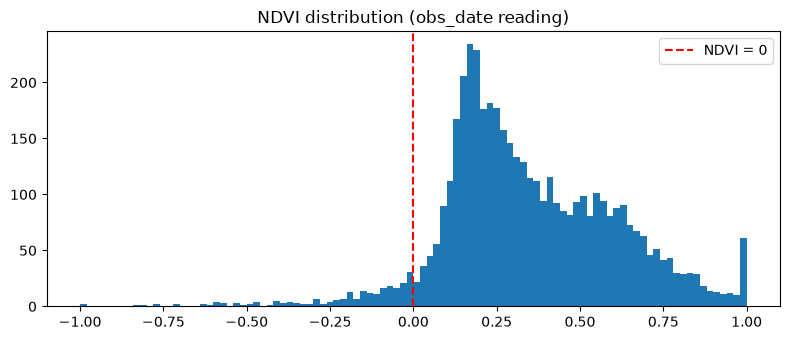

In [7]:
fig, ax = plt.subplots(figsize=(8,3.5))
ax.hist(panel.ndvi, bins=100)
ax.axvline(0, color='r', ls='--', label='NDVI = 0')
ax.set_title('NDVI distribution (obs_date reading)'); ax.legend()
plt.tight_layout()

neg = panel.ndvi < 0
print(f"rows with NDVI < 0: {neg.sum()} ({neg.mean():.2%})")
print(f"rows at exactly -1.0 (NIR = 0, a no-data sentinel): {(panel.ndvi == -1.0).sum()}")

## 5. `forward_z` tails

`forward_z` is a z-score by construction (peer-standardised NDVI one interval ahead), so it should
sit within a few units of zero. It does not.

range: -11.35 .. 7.08   sd: 1.1446


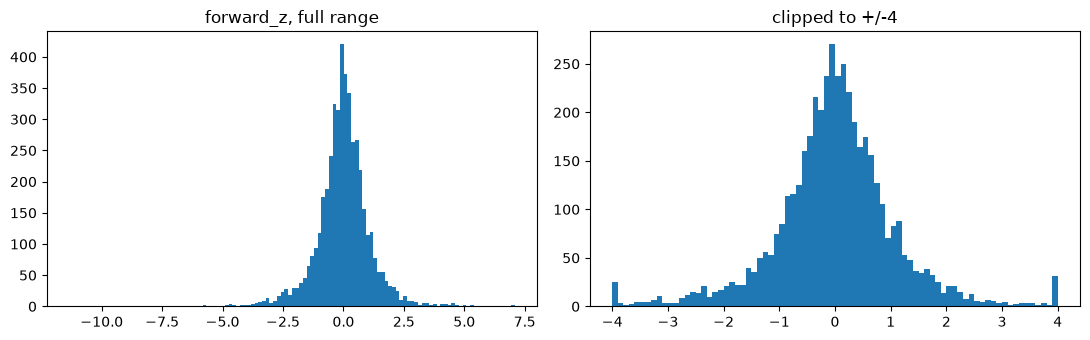

In [8]:
fz = panel.forward_z
print(f"range: {fz.min():.2f} .. {fz.max():.2f}   sd: {fz.std():.4f}")
fig, ax = plt.subplots(1, 2, figsize=(11,3.5))
ax[0].hist(fz, bins=120); ax[0].set_title('forward_z, full range')
ax[1].hist(fz.clip(-4,4), bins=80); ax[1].set_title('clipped to +/-4')
plt.tight_layout()

The tail is not noise: rows with `|forward_z| > 3` are enriched for a **negative label-date
NDVI** -- the label observation itself (30 days after `obs_date`) was invalid, not merely low. The
panel does not carry the label observation's NDVI as its own column (only the arithmetic result,
`forward_z`, survives the build); it is recovered here by looking up, per site, the row whose
`obs_date` equals this row's `label_date`.

In [9]:
lookup = panel.set_index(['site_id','obs_date'])['ndvi']
idx = pd.MultiIndex.from_arrays([panel.site_id, panel.label_date])
label_ndvi = lookup.reindex(idx).to_numpy()
panel = panel.assign(label_ndvi=label_ndvi)

matched = panel['label_ndvi'].notna()
neg_label = panel['label_ndvi'] < 0                       # NaN (no match) counts as not-negative
base_rate = neg_label[matched].mean()                      # base rate, over rows with a resolvable label

tail = panel.forward_z.abs() > 3
tail_rate = neg_label[tail].mean()                         # tail rate, over ALL |z|>3 rows

print(f"base rate (negative label-date NDVI): {base_rate:.1%}  (n={matched.sum()} resolvable)")
print(f"tail rate  (|z|>3, n={tail.sum()}): {tail_rate:.1%}")
print(f"enrichment: {tail_rate/base_rate:.1f}x")

base rate (negative label-date NDVI): 5.1%  (n=4204 resolvable)
tail rate  (|z|>3, n=121): 39.7%
enrichment: 7.8x


## 6. Seasonality: NDVI by calendar month, per cluster

The growing seasons differ by cluster -- this is exactly what the peer cohort's month key
(`cluster|MM` / the geographic band's `|MM`) exists to hold constant when standardising.

cluster,Benue_River_Basin,Kaduna_Grain_Belt,Kano_Sudan_Savannah,Kenya_Rift_Valley
month,,,,
1,0.337,0.249,0.196,0.512
2,0.232,0.196,0.149,0.366
3,0.244,0.203,0.182,0.386
4,0.251,0.197,0.170,0.472
5,0.109,0.200,0.150,0.575
6,0.513,0.276,0.170,0.571
7,NaN,0.322,0.259,0.490
8,NaN,0.581,0.376,0.523
9,NaN,0.392,0.484,0.501


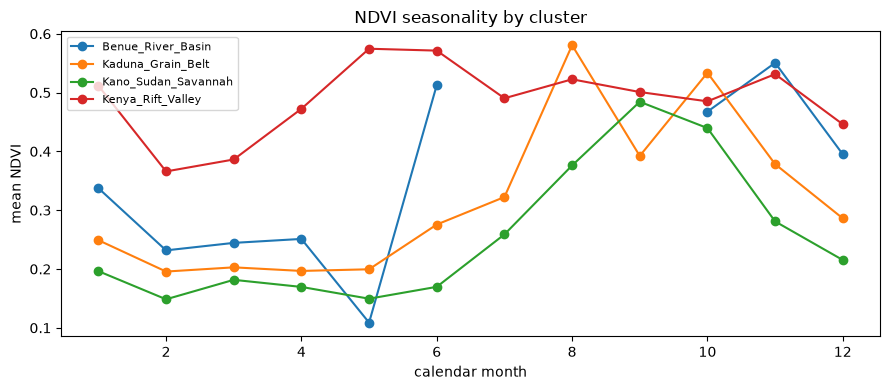

In [10]:
panel['month'] = panel.obs_date.dt.month
seasonal = panel.groupby(['cluster','month']).ndvi.mean().unstack('cluster')
fig, ax = plt.subplots(figsize=(9,4))
seasonal.plot(ax=ax, marker='o')
ax.set_xlabel('calendar month'); ax.set_ylabel('mean NDVI'); ax.set_title('NDVI seasonality by cluster')
ax.legend(fontsize=8)
plt.tight_layout()
seasonal.round(3)

## Sources

Full citation list, with the verified/unverified split, lives in [`docs/CONCEPTS.md`](../docs/CONCEPTS.md)
(Part 1, spectral indices); this section points at what this notebook's panel columns are, without
duplicating the formulas.

- **NDVI** (§4): Rouse, J.W. et al. (1974), ERTS symposium — **[UNVERIFIED]** —
  [`docs/CONCEPTS.md` § NDVI](../docs/CONCEPTS.md#ndvi--normalised-difference-vegetation-index).
- **SAVI**: Huete, A.R. (1988), *Remote Sensing of Environment* 25:295–309 — **[verified]** —
  [§ SAVI](../docs/CONCEPTS.md#savi--soil-adjusted-vegetation-index).
- **EVI**: Huete, A. et al. (2002), *RSE* 83:195–213 — **[verified]** —
  [§ EVI](../docs/CONCEPTS.md#evi--enhanced-vegetation-index).
- **NDMI**: Gao, B.-C. (1996) — **[UNVERIFIED]** —
  [§ NDMI](../docs/CONCEPTS.md#ndmi--normalised-difference-moisture-index).
- **VCI**: Kogan, F.N. (1990), *International Journal of Remote Sensing* 11:1405–1419,
  [https://doi.org/10.1080/01431169008955102](https://doi.org/10.1080/01431169008955102) —
  **[verified]** — [§ VCI](../docs/CONCEPTS.md#vci--vegetation-condition-index).

SAVI, EVI, NDMI and VCI are panel columns this notebook reads and displays (§1 head, missingness in
§3) but does not itself compute or discuss beyond NDVI (§4) and the `forward_z` tails built on it
(§5); the citations above are carried for completeness since the columns are present. **Not
citable:** the tail-enrichment finding in §5 (rows with `|forward_z| > 3` enriched for negative
label-date NDVI) is a **measurement from this repository** — see
[`docs/CONCEPTS.md`'s opening section](../docs/CONCEPTS.md#on-warrants-and-what-no-source-means).